# CLIP Vocabulary Readout
### What words does CLIP associate most strongly with your image?

This notebook extracts the **real vocabulary that is built into the CLIP tokenizer** and scores every word against your uploaded image — returning the top 100 matches.

**How it works:**  
CLIP uses a BPE (Byte Pair Encoding) tokenizer with ~49,000 tokens. Most of these are subword fragments (`"run"`, `"ning"`, `"##tion"`), but tokens that end with the special marker `</w>` are **complete words**. By extracting only those, we get a list of ~20,000 real English words that live inside the model — no hand-curated list needed.

We then encode every word as `"a photo of {word}"`, compute cosine similarity against your image embedding, and return the highest-scoring ones.

**Sections:**
1. Install & imports
2. Pick and load a model
3. Extract the tokenizer vocabulary
4. Pre-compute word embeddings (one-time, cached per model)
5. Upload an image → get top-100 words
6. Model comparison

---
## 1. Install & Imports

In [1]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                'open_clip_torch', 'torch', 'torchvision', 'pillow', 'ipywidgets', 'tqdm'], check=True)
print('ready')

ready


In [2]:
import os, io, pickle
import torch
import open_clip
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import ipywidgets as widgets
from IPython.display import display
from tqdm.notebook import tqdm

os.makedirs('./hf_cache',    exist_ok=True)
os.makedirs('./vocab_cache', exist_ok=True)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'device: {device}')

device: cuda


---
## 2. Pick and Load a Model

In [4]:
MODEL_CHOICES = {
    'ViT-B/32  (fast, 512-dim)':        ('ViT-B-32',  'laion2b_s34b_b79k'),
    'ViT-L/14  (precise, 768-dim, 3x)': ('ViT-L-14',  'laion2b_s32b_b82k'),
    'ViT-H/14  (best, 1024-dim, 6x)':   ('ViT-H-14',  'laion2b_s32b_b79k'),
}

model_dd = widgets.Dropdown(
    options=list(MODEL_CHOICES),
    description='Model:',
    layout=widgets.Layout(width='55%')
)
display(model_dd)
print('Select a model, then run the next cell.')

Dropdown(description='Model:', layout=Layout(width='55%'), options=('ViT-B/32  (fast, 512-dim)', 'ViT-L/14  (p…

Select a model, then run the next cell.


In [5]:
MODEL_NAME, PRETRAINED = MODEL_CHOICES[model_dd.value]

model, _, preprocess = open_clip.create_model_and_transforms(
    MODEL_NAME, pretrained=PRETRAINED, cache_dir='./hf_cache')
model = model.to(device).eval()
tokenizer = open_clip.get_tokenizer(MODEL_NAME)

print(f'Loaded : {MODEL_NAME}  ({PRETRAINED})')
print(f'Embedding dimension : {model.visual.output_dim}')

open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loaded : ViT-B-32  (laion2b_s34b_b79k)
Embedding dimension : 512


---
## 3. Extract the Tokenizer Vocabulary

CLIP's tokenizer is a **Byte Pair Encoding (BPE)** tokenizer — the same technique used in GPT-2. It splits text into subword pieces to handle rare and unknown words.

In BPE, a token that ends with `</w>` marks the **end of a complete word**. For example:

```
"running" → tokens: ["run", "ning</w>"]    <- two subword pieces
"dog"     → tokens: ["dog</w>"]             <- one token = one complete word
```

By keeping only `</w>` tokens and stripping that suffix, we get the full list of complete words that CLIP can recognise as single tokens — its true atomic vocabulary.

In [6]:
def extract_words(tokenizer, min_len=3, max_len=20):
    """
    Pull complete words from CLIP's BPE tokenizer.
    Complete words end with '</w>' in the BPE vocabulary.
    We keep only purely alphabetic words of a sensible length.
    """
    try:
        raw_vocab = tokenizer.encoder           # open_clip SimpleTokenizer
    except AttributeError:
        raw_vocab = tokenizer.tokenizer.encoder  # wrapped variant

    words = []
    for token in raw_vocab:
        if token.endswith('</w>'):
            word = token[:-4]                   # strip '</w>'
            if word.isalpha() and min_len <= len(word) <= max_len:
                words.append(word.lower())

    return sorted(set(words))


WORDS = extract_words(tokenizer)

print(f'Words extracted from {MODEL_NAME} tokenizer: {len(WORDS)}')
rng    = np.random.default_rng(42)
sample = rng.choice(WORDS, size=30, replace=False).tolist()
print('Random sample of 30:', ', '.join(sorted(sample)))

Words extracted from ViT-B-32 tokenizer: 32495
Random sample of 30: baseball, bbloggers, beli, btsarmy, combating, cosmic, goodwood, hendricks, imminent, industrial, innovator, invest, leaders, lio, lung, maw, parity, perceived, puli, recreational, revolutionary, sap, sec, severe, shaving, sphinx, stitch, swamy, unmanned, wore


---
## 4. Pre-Compute Word Embeddings

We encode every word as `"a photo of {word}"` and store the embeddings on disk.

**First run:** 1–3 minutes on CPU. **Subsequent runs:** instant (loads from cache).

In [7]:
CACHE_FILE = f'./vocab_cache/words_{MODEL_NAME.replace("/","-")}.pkl'

if os.path.exists(CACHE_FILE):
    print(f'Loading from cache: {CACHE_FILE}')
    with open(CACHE_FILE, 'rb') as f:
        cache = pickle.load(f)
    if cache['words'] == WORDS:
        word_embeddings = cache['embeddings']
        print(f'Loaded {word_embeddings.shape[0]} word embeddings  (dim={word_embeddings.shape[1]})')
    else:
        print('Cache word list changed — recomputing.')
        os.remove(CACHE_FILE)

if not os.path.exists(CACHE_FILE):
    print(f'Encoding {len(WORDS)} words ... (this runs once)')
    prompts   = [f'a photo of {w}' for w in WORDS]
    all_feats = []
    for i in tqdm(range(0, len(prompts), 256), desc='batches'):
        chunk = prompts[i:i+256]
        with torch.no_grad():
            toks  = tokenizer(chunk).to(device)
            feats = model.encode_text(toks).float()
            feats = feats / feats.norm(dim=-1, keepdim=True)
            all_feats.append(feats.cpu())
    word_embeddings = torch.cat(all_feats, dim=0)
    with open(CACHE_FILE, 'wb') as f:
        pickle.dump({'words': WORDS, 'embeddings': word_embeddings}, f)
    print(f'Saved to {CACHE_FILE}')

print(f'Word embedding matrix: {word_embeddings.shape}   (words x embedding dim)')

Encoding 32495 words ... (this runs once)


batches:   0%|          | 0/127 [00:00<?, ?it/s]

Saved to ./vocab_cache/words_ViT-B-32.pkl
Word embedding matrix: torch.Size([32495, 512])   (words x embedding dim)


---
## 5. Upload an Image and Get the Top-100 Words

CLIP will score your image against all ~20,000 words in the tokenizer vocabulary and show you the 100 with the highest cosine similarity.

In [8]:
uploader = widgets.FileUpload(
    accept='image/*', multiple=False,
    description='Upload image',
    layout=widgets.Layout(width='180px')
)

top_n_slider = widgets.IntSlider(
    value=100, min=20, max=200, step=10,
    description='Top N:',
    layout=widgets.Layout(width='360px')
)

run_btn = widgets.Button(
    description='Run readout',
    button_style='primary',
    layout=widgets.Layout(width='150px')
)
out = widgets.Output()


def run_readout(_):
    out.clear_output()
    with out:
        if not uploader.value:
            print('Please upload an image first.')
            return

        # ipywidgets 8.x: .value is a tuple
        file_info = uploader.value[0]
        pil_img   = Image.open(io.BytesIO(file_info['content'])).convert('RGB')

        # Encode image
        img_t = preprocess(pil_img).unsqueeze(0).to(device)
        with torch.no_grad():
            img_feat = model.encode_image(img_t).float()
            img_feat = img_feat / img_feat.norm(dim=-1, keepdim=True)
        img_feat = img_feat.cpu()

        # Score all words
        scores   = (img_feat @ word_embeddings.T).squeeze(0).numpy()
        top_n    = top_n_slider.value
        top_idx  = np.argsort(scores)[::-1][:top_n]
        top_words  = [WORDS[i]  for i in top_idx]
        top_scores = [scores[i] for i in top_idx]

        # Colour bars by score tier
        def bar_colour(s):
            if   s > 0.30: return '#c0392b'
            elif s > 0.25: return '#e67e22'
            elif s > 0.20: return '#3498db'
            else:          return '#95a5a6'

        colours = [bar_colour(s) for s in top_scores]

        # Layout
        bar_h = 0.28
        fig_h = max(8, top_n * (bar_h + 0.04) + 2)
        fig, axes = plt.subplots(1, 2, figsize=(16, fig_h),
                                  gridspec_kw={'width_ratios': [1, 3]})

        # Image preview
        preview = pil_img.copy(); preview.thumbnail((300, 300))
        axes[0].imshow(preview); axes[0].axis('off')
        axes[0].set_title(
            f'{MODEL_NAME}\n{model.visual.output_dim}-dim embedding\n'
            f'vocab: {len(WORDS)} words', fontsize=9)

        # Bar chart
        y = np.arange(top_n)
        axes[1].barh(y, top_scores[::-1], color=colours[::-1], height=bar_h)
        axes[1].set_yticks(y)
        axes[1].set_yticklabels(top_words[::-1], fontsize=max(5, 9 - top_n // 40))
        axes[1].set_xlabel('Cosine similarity  (prompt: "a photo of {word}")', fontsize=9)
        axes[1].set_title(
            f'Top {top_n} words from {MODEL_NAME} tokenizer vocabulary ({len(WORDS)} words total)',
            fontsize=10)

        legend = [
            mpatches.Patch(color='#c0392b', label='> 0.30  very strong'),
            mpatches.Patch(color='#e67e22', label='> 0.25  strong'),
            mpatches.Patch(color='#3498db', label='> 0.20  moderate'),
            mpatches.Patch(color='#95a5a6', label='<= 0.20  weak'),
        ]
        axes[1].legend(handles=legend, fontsize=8, loc='lower right')

        plt.tight_layout()
        plt.show()

        print(f'\nTop 20 words  |  model: {MODEL_NAME}  |  vocab: {len(WORDS)} words')
        print(f'{"rank":>5}  {"word":<22}  score')
        print('─' * 42)
        for rank, (w, s) in enumerate(zip(top_words[:20], top_scores[:20])):
            print(f'{rank+1:>5}  {w:<22}  {s:.4f}')


run_btn.on_click(run_readout)
display(widgets.VBox([uploader, top_n_slider, run_btn, out]))

---
## 6. Model Comparison

Loads all three models one at a time and shows their top-30 words side by side for the same image.

Things to look for:
- **Shared words** — concepts all three models agree on
- **Words unique to larger models** — finer-grained semantics ViT-L/H pick up that ViT-B misses
- **Score spread** — larger models often give more peaked, confident distributions

> Memory note: each model is freed from RAM before the next one loads.


── ViT-B/32 ────────────────────────────────────
  vocabulary: 32495 words
  word embeddings loaded from cache

── ViT-L/14 ────────────────────────────────────


open_clip_pytorch_model.bin:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

  vocabulary: 32495 words


  encoding:   0%|          | 0/127 [00:00<?, ?it/s]

  saved to cache

── ViT-H/14 ────────────────────────────────────


open_clip_model.safetensors:   0%|          | 0.00/3.94G [00:00<?, ?B/s]

  vocabulary: 32495 words


  encoding:   0%|          | 0/127 [00:00<?, ?it/s]

  saved to cache


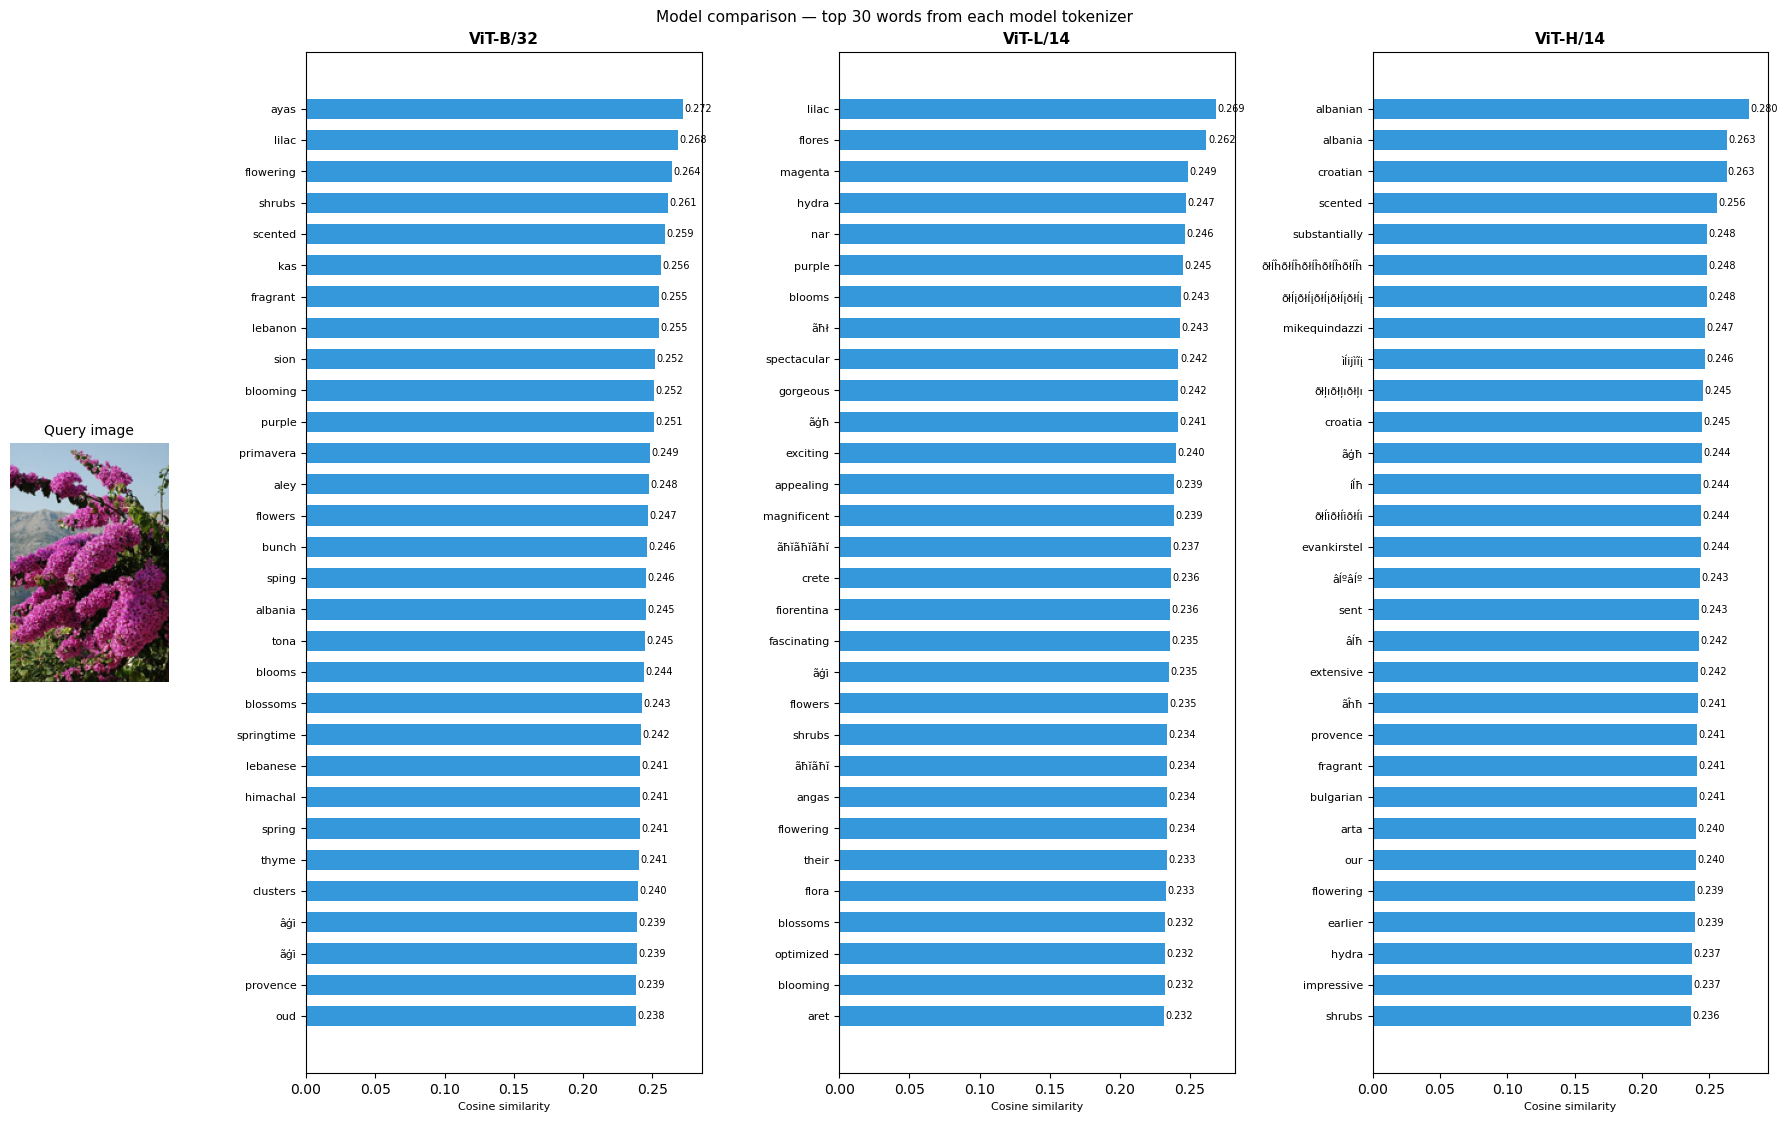


Rank  ViT-B/32                    ViT-L/14                    ViT-H/14                    
──────────────────────────────────────────────────────────────────────────────────────────
#1    ayas                 0.272   lilac                0.269   albanian             0.280   
#2    lilac                0.268   flores               0.262   albania              0.263   
#3    flowering            0.264   magenta              0.249   croatian             0.263   
#4    shrubs               0.261   hydra                0.247   scented              0.256   
#5    scented              0.259   nar                  0.246   substantially        0.248   
#6    kas                  0.256   purple               0.245   ðłĺĥðłĺĥðłĺĥðłĺĥðłĺĥ 0.248   
#7    fragrant             0.255   blooms               0.243   ðłĺįðłĺįðłĺįðłĺįðłĺį 0.248   
#8    lebanon              0.255   ãħł                  0.243   mikequindazzi        0.247   
#9    sion                 0.252   spectacular          0.242   ì

In [9]:
TOP_COMPARE = 30

COMPARE_MODELS = [
    ('ViT-B/32', 'ViT-B-32', 'laion2b_s34b_b79k'),
    ('ViT-L/14', 'ViT-L-14', 'laion2b_s32b_b82k'),
    ('ViT-H/14', 'ViT-H-14', 'laion2b_s32b_b79k'),  # comment out if low on RAM
]

if not uploader.value:
    print('Upload an image in cell 5 first, then re-run this cell.')
else:
    file_info = uploader.value[0]
    query_img = Image.open(io.BytesIO(file_info['content'])).convert('RGB')

    results = {}

    for label, arch, pretrained in COMPARE_MODELS:
        print(f'\n── {label} ────────────────────────────────────')

        m, _, prep = open_clip.create_model_and_transforms(
            arch, pretrained=pretrained, cache_dir='./hf_cache')
        m   = m.to(device).eval()
        tok = open_clip.get_tokenizer(arch)

        # Extract this model's word list
        try:
            rv = tok.encoder
        except AttributeError:
            rv = tok.tokenizer.encoder
        words_m = sorted(set(
            t[:-4].lower() for t in rv
            if t.endswith('</w>') and t[:-4].isalpha() and 3 <= len(t[:-4]) <= 20
        ))
        print(f'  vocabulary: {len(words_m)} words')

        # Load or compute word embeddings
        cf = f'./vocab_cache/words_{arch.replace("/","-")}.pkl'
        if os.path.exists(cf):
            with open(cf, 'rb') as f:
                c = pickle.load(f)
            w_emb = c['embeddings'] if c['words'] == words_m else None
        else:
            w_emb = None

        if w_emb is None:
            prompts = [f'a photo of {w}' for w in words_m]
            parts   = []
            for i in tqdm(range(0, len(prompts), 256), desc='  encoding', leave=False):
                with torch.no_grad():
                    t = tok(prompts[i:i+256]).to(device)
                    f = m.encode_text(t).float()
                    f = f / f.norm(dim=-1, keepdim=True)
                    parts.append(f.cpu())
            w_emb = torch.cat(parts, dim=0)
            with open(cf, 'wb') as f:
                pickle.dump({'words': words_m, 'embeddings': w_emb}, f)
            print(f'  saved to cache')
        else:
            print(f'  word embeddings loaded from cache')

        img_t = prep(query_img).unsqueeze(0).to(device)
        with torch.no_grad():
            img_f = m.encode_image(img_t).float()
            img_f = img_f / img_f.norm(dim=-1, keepdim=True)
        img_f   = img_f.cpu()
        sc      = (img_f @ w_emb.T).squeeze(0).numpy()
        top_idx = np.argsort(sc)[::-1][:TOP_COMPARE]
        results[label] = ([words_m[i] for i in top_idx], [sc[i] for i in top_idx])

        del m, tok, w_emb, img_f
        if device == 'cuda': torch.cuda.empty_cache()

    # Side-by-side plot
    n   = len(results)
    fig, axes = plt.subplots(1, n + 1,
                              figsize=(5 * n + 3, max(8, TOP_COMPARE * 0.38)),
                              gridspec_kw={'width_ratios': [1] + [2.5] * n})
    preview = query_img.copy(); preview.thumbnail((200, 200))
    axes[0].imshow(preview); axes[0].axis('off')
    axes[0].set_title('Query image', fontsize=10)

    for ax, (label, (words, scores)) in zip(axes[1:], results.items()):
        y = np.arange(TOP_COMPARE)
        ax.barh(y, scores[::-1], color='#3498db', height=0.65)
        ax.set_yticks(y)
        ax.set_yticklabels(words[::-1], fontsize=8)
        ax.set_title(label, fontsize=11, fontweight='bold')
        ax.set_xlabel('Cosine similarity', fontsize=8)
        for bar, s in zip(ax.patches, scores[::-1]):
            ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                    f'{s:.3f}', va='center', fontsize=7)

    plt.suptitle(f'Model comparison — top {TOP_COMPARE} words from each model tokenizer', fontsize=11)
    plt.tight_layout()
    plt.show()

    # Agreement table
    model_labels = list(results.keys())
    print(f'\n{"Rank":<6}', end='')
    for lbl in model_labels: print(f'{lbl:<28}', end='')
    print()
    print('─' * (6 + 28 * n))
    for rank in range(min(20, TOP_COMPARE)):
        print(f'#{rank+1:<5}', end='')
        for lbl in model_labels:
            w, s = results[lbl]
            print(f'{w[rank]:<20} {s[rank]:.3f}   ', end='')
        print()

    sets   = [set(results[lbl][0]) for lbl in model_labels]
    shared = sets[0].intersection(*sets[1:])
    print(f'\nWords in top {TOP_COMPARE} of ALL models ({len(shared)}): {sorted(shared)}')
    for lbl in model_labels:
        others = set().union(*[results[l][0] for l in model_labels if l != lbl])
        unique = set(results[lbl][0]) - others
        if unique:
            print(f'Unique to {lbl}: {sorted(unique)}')

---
## Notes on the Results

**Why ~20,000 words and not 49,000?**  
The BPE vocabulary has ~49,000 tokens, but most are subword fragments. Only `</w>` tokens are complete words. Filtering for alphabetic strings of 3–20 characters leaves roughly 20,000 real English words.

**Why `"a photo of {word}"`?**  
Encoding bare words gives weaker embeddings. Wrapping them in a sentence gives the text encoder proper context. The original CLIP paper showed this prompt engineering step significantly improves accuracy.

**Score ranges for real images:**
- `> 0.30` — very strong match, the concept is central to the image
- `0.25–0.30` — strong match
- `0.20–0.25` — moderate match
- `< 0.20` — weak / coincidental

**Why do larger models give different answers?**  
ViT-L/14 and ViT-H/14 use 14×14 pixel patches (vs 32×32 for ViT-B/32), giving them more spatial tokens per image. They also have more attention layers. Together this makes them sensitive to finer visual details — specific textures, sub-objects, lighting — that the smaller model averages away.